# Residual StandardCNN — Tiny ImageNet 200 Classes

**Controlled AdamW experiment — Direct Cosine LR**

- Channels: `48 → 96 → 192 → 384`
- **2 residual blocks per stage**
- Trained **from scratch**
- CE + label smoothing
- **AdamW**
- **CosineAnnealingLR: 0.001 → 0.00001**
- Maximum epochs: **90**
- Minimum epochs before early stopping: **60**
- Early stopping patience after epoch 60: **15 epochs**
- Feature dropout: **0.10**
- Label smoothing: **0.05**
- AdamW weight decay: **1e-4**
- Dataset: **450 train/class + 100 validation/class**
- Batch size: **64**
- Seed: **42**
- No AugMix / JSD / MixUp / CutMix
- RGB input is retained

The residual architecture and data pipeline are intentionally unchanged so this run mainly tests AdamW against the SGD + Cosine setup.

## 1. Imports

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from IPython.display import display
from matplotlib import pyplot as plt
from torchvision import transforms

from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset_450train_100val import TinyImageNetLoader, show_image, get_tiny_imagenet_class_names, test_transform, means, stds, convert_to_rgb
from cnn_exp.cnn_residual import StandardCNN

print("PyTorch:", torch.__version__)

PyTorch: 2.13.0


## 2. Configuration

In [2]:
SEED = 42

NUM_CLASSES = 200
SELECTED_CLASSES = list(range(NUM_CLASSES))
TRAIN_IMAGES_PER_CLASS = 450
VAL_IMAGES_PER_CLASS = 100

BATCH_SIZE = 64
NUM_WORKERS = 4

EPOCHS = 90
SCREENING_EPOCHS = 32

INITIAL_LR = 1e-3
MIN_LR = 1e-5

ADAMW_WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.10
FEATURE_DROPOUT = 0.20

MIN_EPOCHS_BEFORE_EARLY_STOP = 15
EARLY_STOPPING_PATIENCE = 7

# MIN_EPOCHS_BEFORE_EARLY_STOP = 60
# EARLY_STOPPING_PATIENCE = 15
#
# INITIAL_LR = 1e-3
# MIN_LR = 1e-5
#
# ADAMW_WEIGHT_DECAY = 1e-4
# LABEL_SMOOTHING = 0.05
# FEATURE_DROPOUT = 0.10

TINY_ROOT = Path("../../../data/tiny_imagenet/tiny-imagenet-200-450train-100val")
SAVE_PATH = Path(f"residual_cnn_2blocks_ce_adamw_cosine_{NUM_CLASSES}class_{TRAIN_IMAGES_PER_CLASS}train_seed{SEED}.pth")

print("Dataset:", TINY_ROOT)
print("Checkpoint:", SAVE_PATH)
print("Max epochs:", EPOCHS)
print("Initial LR:", INITIAL_LR)
print("Minimum LR:", MIN_LR)
print("Minimum epochs before early stopping:", MIN_EPOCHS_BEFORE_EARLY_STOP)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE, "epochs")

Dataset: ../data/tiny_imagenet/tiny-imagenet-200-450train-100val
Checkpoint: residual_cnn_2blocks_ce_adamw_cosine_200class_450train_seed42.pth
Max epochs: 90
Initial LR: 0.001
Minimum LR: 1e-05
Minimum epochs before early stopping: 15
Early stopping patience: 7 epochs


## 3. Reproducibility and Device

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available(): DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available(): DEVICE = torch.device("mps")
else: DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


## 4. Load Tiny ImageNet

In [4]:
train_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

train_dataset, val_dataset, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=train_transform).load()
train_eval_dataset, _, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=test_transform).load()

if not hasattr(train_eval_dataset, "transform"): raise AttributeError("train_eval_dataset must expose a 'transform' attribute.")
train_eval_dataset.transform = test_transform

print("Full train dataset:", len(train_dataset))
print("Full validation dataset:", len(val_dataset))
print("Full clean train-eval dataset:", len(train_eval_dataset))

print("\nTrain transform:")
print(getattr(train_dataset, "transform", None))
print("\nValidation transform:")
print(getattr(val_dataset, "transform", None))
print("\nClean train-eval transform:")
print(getattr(train_eval_dataset, "transform", None))

assert len(train_dataset) == NUM_CLASSES * TRAIN_IMAGES_PER_CLASS
assert len(val_dataset) == NUM_CLASSES * VAL_IMAGES_PER_CLASS

Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Full train dataset: 90000
Full validation dataset: 20000
Full clean train-eval dataset: 90000

Train transform:
Compose(
    Lambda()
    RandomCrop(size=(64, 64), padding=4)
    RandomHorizontalFlip(p=0.5)
    RandAugment(num_ops=2, magnitude=5, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)

Validation transform:
Compose(
    Lambda()
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)

Clean train-eval transform:
Compose(
    Lambda()
    ToTensor()
    Normalize(mean=[0.4803270399570

## 5. Select All 200 Classes

In [5]:
train_subset = BalancedClassSubset(train_dataset, SELECTED_CLASSES, TRAIN_IMAGES_PER_CLASS, seed=SEED)
train_eval_subset = BalancedClassSubset(train_eval_dataset, SELECTED_CLASSES, TRAIN_IMAGES_PER_CLASS, seed=SEED)
val_subset = BalancedClassSubset(val_dataset, SELECTED_CLASSES, VAL_IMAGES_PER_CLASS, seed=SEED + 1)

FULL_CLASS_NAMES = get_tiny_imagenet_class_names(train_dataset, TINY_ROOT)
CLASS_NAMES = [FULL_CLASS_NAMES[class_id] for class_id in SELECTED_CLASSES]

print("Same selected training samples:", train_subset.samples == train_eval_subset.samples)
print("Selected classes:", len(SELECTED_CLASSES))
print("Training images:", len(train_subset))
print("Clean train-eval images:", len(train_eval_subset))
print("Validation images:", len(val_subset))

assert train_subset.samples == train_eval_subset.samples
assert len(train_dataset) == NUM_CLASSES * TRAIN_IMAGES_PER_CLASS
assert len(val_dataset) == NUM_CLASSES * VAL_IMAGES_PER_CLASS

Same selected training samples: True
Selected classes: 200
Training images: 90000
Clean train-eval images: 90000
Validation images: 20000


## 6. DataLoaders

In [6]:
generator = torch.Generator()
generator.manual_seed(SEED)

persistent_workers = NUM_WORKERS > 0
pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)
train_eval_loader = DataLoader(train_eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)

print("Training batches:", len(train_loader))
print("Clean train-eval batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 1407
Clean train-eval batches: 1407
Validation batches: 313


## 7. Visual Check

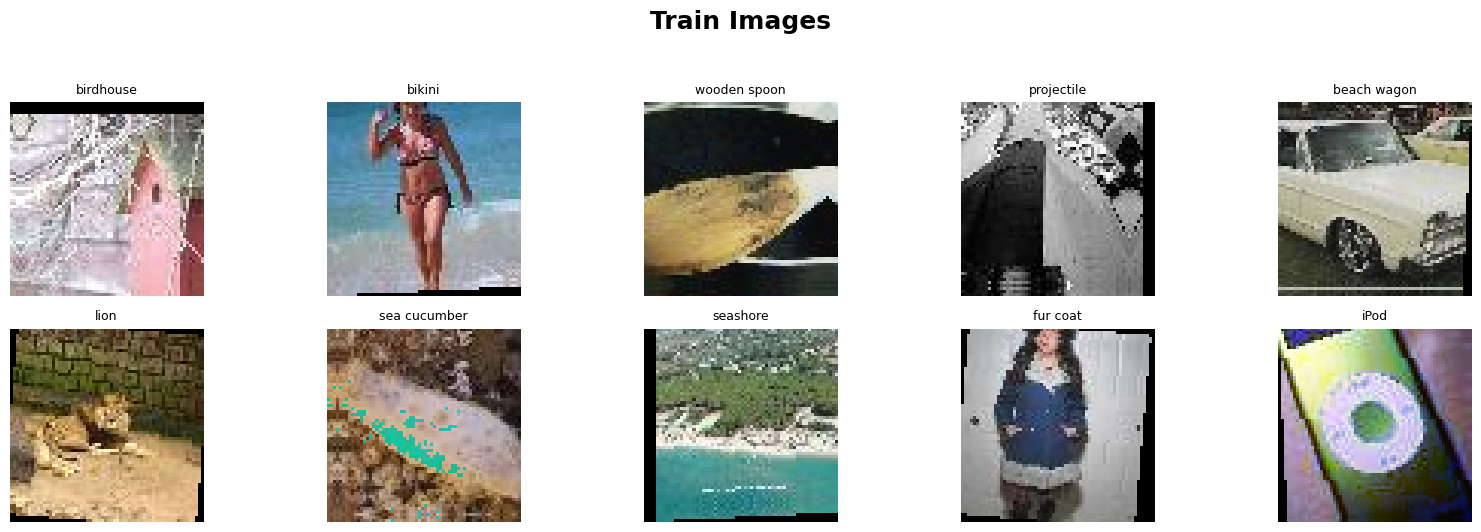

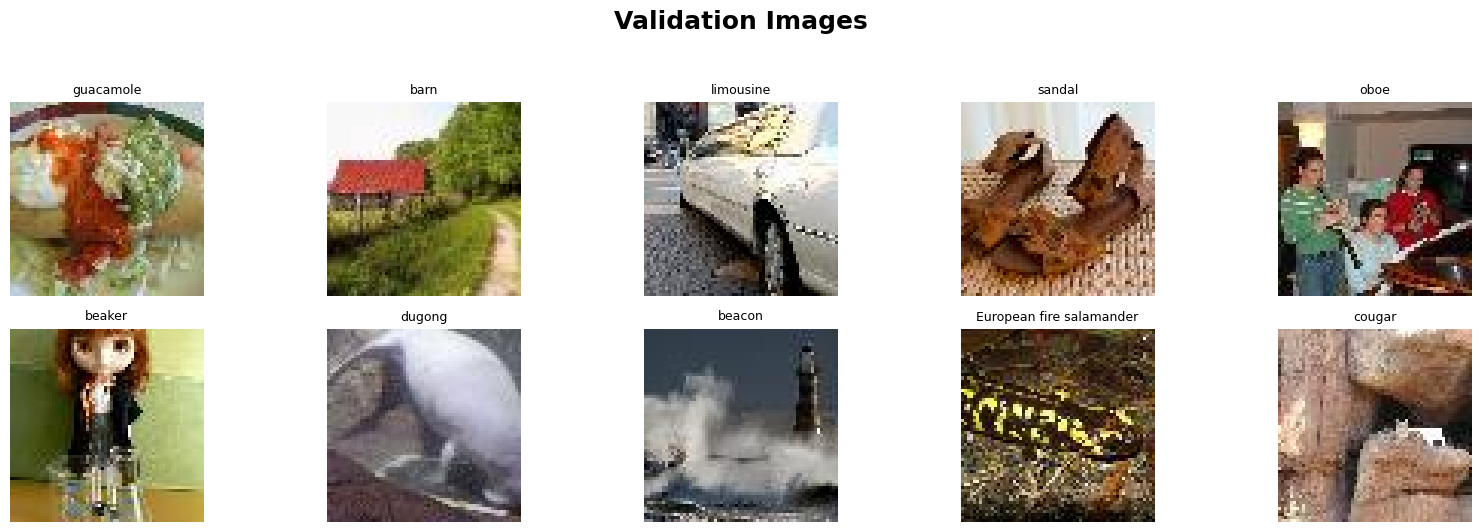

In [7]:
NUM_SHOW = 10

train_images, train_labels = next(iter(train_loader))
val_images, val_labels_batch = next(iter(val_loader))

show_image(train_images, train_labels, NUM_SHOW, CLASS_NAMES, name="Train Images")
show_image(val_images, val_labels_batch, NUM_SHOW, CLASS_NAMES, name="Validation Images")

## 9. Create Model and Verify Shapes

In [8]:
model = StandardCNN(num_classes=NUM_CLASSES, feature_dropout=FEATURE_DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable parameters (M): {trainable_params / 1e6:.3f}M")
print("Expected parameters: 6,361,592")

x = torch.randn(2, 3, 64, 64, device=DEVICE)

model.eval()

with torch.no_grad():
    result = model(x, return_features=True)

print("Input:", x.shape)
print("Stem:", result["stem"].shape)
print("r1:", result["r1"].shape)
print("r2:", result["r2"].shape)
print("r3:", result["r3"].shape)
print("r4:", result["r4"].shape)
print("Features:", result["features"].shape)
print("Scores:", result["scores"].shape)

assert total_params == 6361592
assert result["r1"].shape == (2, 48, 64, 64)
assert result["r2"].shape == (2, 96, 32, 32)
assert result["r3"].shape == (2, 192, 16, 16)
assert result["r4"].shape == (2, 384, 8, 8)
assert result["features"].shape == (2, 384)
assert result["scores"].shape == (2, NUM_CLASSES)

model.train()

Total parameters: 6,361,592
Trainable parameters: 6,361,592
Trainable parameters (M): 6.362M
Expected parameters: 6,361,592
Input: torch.Size([2, 3, 64, 64])
Stem: torch.Size([2, 48, 64, 64])
r1: torch.Size([2, 48, 64, 64])
r2: torch.Size([2, 96, 32, 32])
r3: torch.Size([2, 192, 16, 16])
r4: torch.Size([2, 384, 8, 8])
Features: torch.Size([2, 384])
Scores: torch.Size([2, 200])


StandardCNN(
  (stem): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (level1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): Re

## 10. Loss, AdamW and Direct Cosine LR

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(model.parameters(), lr=INITIAL_LR, weight_decay=ADAMW_WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader),
    eta_min=MIN_LR
)

print("Loss: CrossEntropyLoss")
print("Label smoothing:", LABEL_SMOOTHING)
print("Optimizer: AdamW")
print("Weight decay:", ADAMW_WEIGHT_DECAY)
print("Scheduler: CosineAnnealingLR")
print("Initial LR:", INITIAL_LR)
print("Minimum LR:", MIN_LR)
print("Maximum epochs:", EPOCHS)
print("Minimum epochs before early stopping:", MIN_EPOCHS_BEFORE_EARLY_STOP)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Steps per epoch:", len(train_loader))

Loss: CrossEntropyLoss
Label smoothing: 0.1
Optimizer: AdamW
Weight decay: 0.0005
Scheduler: CosineAnnealingLR
Initial LR: 0.001
Minimum LR: 1e-05
Maximum epochs: 90
Minimum epochs before early stopping: 15
Early stopping patience: 7
Steps per epoch: 1407


## 11. Training Pass

In [10]:
def train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct += (predictions == labels).sum().item()
        total += batch_size

    return {"loss": running_loss / total, "accuracy": 100.0 * correct / total}

## 12. Evaluation Pass

In [11]:
@torch.inference_mode()
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct += (predictions == labels).sum().item()
        total += batch_size
        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())

    return {"loss": running_loss / total, "accuracy": 100.0 * correct / total, "labels": torch.cat(all_labels), "predictions": torch.cat(all_predictions)}

## 13. Train Model

In [12]:
from tqdm import tqdm

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "train_eval_loss": [],
    "train_eval_accuracy": [],
    "train_val_gap": [],
    "clean_train_eval_val_gap": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in tqdm(range(1, SCREENING_EPOCHS + 1)):
    train_result = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, DEVICE)
    val_result = evaluate(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]["lr"]
    train_val_gap = train_result["accuracy"] - val_result["accuracy"]

    history["train_loss"].append(train_result["loss"])
    history["train_accuracy"].append(train_result["accuracy"])
    history["val_loss"].append(val_result["loss"])
    history["val_accuracy"].append(val_result["accuracy"])
    history["train_val_gap"].append(train_val_gap)
    history["learning_rate"].append(current_lr)

    improved = val_result["accuracy"] > best_val_accuracy or (val_result["accuracy"] == best_val_accuracy and val_result["loss"] < best_val_loss)

    if improved:
        best_val_accuracy = val_result["accuracy"]
        best_val_loss = val_result["loss"]
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_result["loss"],
            "train_accuracy": train_result["accuracy"],
            "val_loss": val_result["loss"],
            "val_accuracy": val_result["accuracy"],
            "train_val_gap": train_val_gap,
            "learning_rate": current_lr,
            "num_classes": NUM_CLASSES,
            "seed": SEED,
            "label_smoothing": LABEL_SMOOTHING,
            "feature_dropout": FEATURE_DROPOUT,
            "initial_lr": INITIAL_LR,
            "min_lr": MIN_LR,
            "weight_decay": ADAMW_WEIGHT_DECAY,
            "optimizer": "AdamW",
            "scheduler": "CosineAnnealingLR",
            "min_epochs_before_early_stop": MIN_EPOCHS_BEFORE_EARLY_STOP,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "architecture": "Residual 48-96-192-384",
            "residual_blocks_per_stage": 2,
            "parameter_count": total_params
        }

        torch.save(checkpoint, SAVE_PATH)
        print(f"  -> Best model saved | Epoch: {epoch} | Val Acc: {val_result['accuracy']:.2f}% | Val Loss: {val_result['loss']:.4f}")
    else:
        if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP:
            epochs_without_improvement += 1
        else:
            epochs_without_improvement = 0

    print(f"Epoch [{epoch:03d}/{SCREENING_EPOCHS:03d}] | LR: {current_lr:.6f}")
    print(f"Train      -> Loss: {train_result['loss']:.4f} | Acc: {train_result['accuracy']:.2f}%")
    print(f"Validation -> Loss: {val_result['loss']:.4f} | Acc: {val_result['accuracy']:.2f}%")
    print(f"Train-Val Gap: {train_val_gap:.2f} pp")
    print(f"Best Val Acc: {best_val_accuracy:.2f}% @ Epoch {best_epoch}")
    if epoch < MIN_EPOCHS_BEFORE_EARLY_STOP:
        print(f"Early stopping: inactive until epoch {MIN_EPOCHS_BEFORE_EARLY_STOP}")
    else:
        print(f"Epochs without improvement: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")
    print("-" * 90)

    if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}. No validation improvement for {EARLY_STOPPING_PATIENCE} consecutive eligible epochs.")
        break

print("=" * 90)
print(f"Best Epoch: {best_epoch} | Best Val Acc: {best_val_accuracy:.2f}% | Best Val Loss: {best_val_loss:.6f}")
print("Best model saved to:", SAVE_PATH)

  3%|▎         | 1/32 [05:48<2:59:54, 348.21s/it]

  -> Best model saved | Epoch: 1 | Val Acc: 12.46% | Val Loss: 4.2512
Epoch [001/032] | LR: 0.001000
Train      -> Loss: 4.7503 | Acc: 5.71%
Validation -> Loss: 4.2512 | Acc: 12.46%
Train-Val Gap: -6.75 pp
Best Val Acc: 12.46% @ Epoch 1
Early stopping: inactive until epoch 15
------------------------------------------------------------------------------------------


  6%|▋         | 2/32 [11:34<2:53:36, 347.23s/it]

  -> Best model saved | Epoch: 2 | Val Acc: 19.32% | Val Loss: 3.9291
Epoch [002/032] | LR: 0.000999
Train      -> Loss: 4.1517 | Acc: 14.77%
Validation -> Loss: 3.9291 | Acc: 19.32%
Train-Val Gap: -4.55 pp
Best Val Acc: 19.32% @ Epoch 2
Early stopping: inactive until epoch 15
------------------------------------------------------------------------------------------


  9%|▉         | 3/32 [17:18<2:46:57, 345.44s/it]

...

  -> Best model saved | Epoch: 30 | Val Acc: 57.52% | Val Loss: 2.5097
Epoch [030/032] | LR: 0.000752
Train      -> Loss: 1.8239 | Acc: 75.37%
Validation -> Loss: 2.5097 | Acc: 57.52%
Train-Val Gap: 17.85 pp
Best Val Acc: 57.52% @ Epoch 30
Epochs without improvement: 0/7
------------------------------------------------------------------------------------------


 97%|█████████▋| 31/32 [2:56:57<05:40, 340.95s/it]

Epoch [031/032] | LR: 0.000737
Train      -> Loss: 1.7983 | Acc: 76.27%
Validation -> Loss: 2.5190 | Acc: 57.01%
Train-Val Gap: 19.26 pp
Best Val Acc: 57.52% @ Epoch 30
Epochs without improvement: 1/7
------------------------------------------------------------------------------------------


100%|██████████| 32/32 [3:02:40<00:00, 342.53s/it]

Epoch [032/032] | LR: 0.000722
Train      -> Loss: 1.7735 | Acc: 76.94%
Validation -> Loss: 2.5211 | Acc: 57.04%
Train-Val Gap: 19.90 pp
Best Val Acc: 57.52% @ Epoch 30
Epochs without improvement: 2/7
------------------------------------------------------------------------------------------
Best Epoch: 30 | Best Val Acc: 57.52% | Best Val Loss: 2.509657
Best model saved to: residual_cnn_2blocks_ce_adamw_cosine_200class_450train_seed42.pth


## 14. Load Best Model and Re-Evaluate

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

best_train_eval_result = evaluate(model, train_eval_loader, criterion, DEVICE)
best_val_result = evaluate(model, val_loader, criterion, DEVICE)

best_train_val_gap = checkpoint["train_accuracy"] - best_val_result["accuracy"]
best_clean_train_eval_val_gap = best_train_eval_result["accuracy"] - best_val_result["accuracy"]

print("RESIDUAL STANDARD CNN 384 — 2 BLOCKS/STAGE — ADAMW + COSINE")
print("=" * 80)
print(f"Best Epoch: {checkpoint['epoch']}")
print(f"Train      -> Loss: {checkpoint['train_loss']:.4f} | Acc: {checkpoint['train_accuracy']:.2f}%")
print(f"Validation -> Loss: {best_val_result['loss']:.4f} | Acc: {best_val_result['accuracy']:.2f}%")
print(f"Train-Val Gap: {best_train_val_gap:.2f} pp")
print("Additional:")
print(f"Clean Train Eval -> Loss: {best_train_eval_result['loss']:.4f} | Acc: {best_train_eval_result['accuracy']:.2f}%")
print(f"Clean Train Eval-Val Gap: {best_clean_train_eval_val_gap:.2f} pp")
print("=" * 80)

## 15. Feature Extraction

In [ ]:
@torch.inference_mode()
def extract_features(model, data_loader, device):
    model.eval()

    all_features = []
    all_labels = []

    for images, labels in data_loader:
        images = images.to(device)
        result = model(images, return_features=True)
        all_features.append(result["features"].cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_features, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

val_features, val_labels = extract_features(model, val_loader, DEVICE)

print("Feature shape:", val_features.shape)
print("Label shape:", val_labels.shape)

## 16. Feature Separation

In [ ]:
def calculate_feature_separation(features, labels, num_classes):
    class_centers = []
    intra_distances = []

    for class_id in range(num_classes):
        class_features = features[labels == class_id]
        center = class_features.mean(axis=0)
        class_centers.append(center)
        intra_distances.extend(np.linalg.norm(class_features - center, axis=1))

    class_centers = np.stack(class_centers)
    inter_distances = []

    for i in range(num_classes):
        for j in range(i + 1, num_classes): inter_distances.append(np.linalg.norm(class_centers[i] - class_centers[j]))

    mean_intra_distance = np.mean(intra_distances)
    mean_inter_distance = np.mean(inter_distances)
    separation_ratio = mean_inter_distance / mean_intra_distance

    return {"mean_intra_distance": mean_intra_distance, "mean_inter_distance": mean_inter_distance, "separation_ratio": separation_ratio}

separation = calculate_feature_separation(val_features, val_labels, NUM_CLASSES)

print("FEATURE SEPARATION — RESIDUAL ADAMW + COSINE")
print("=" * 60)
print(f"Mean Intra-Class Distance : {separation['mean_intra_distance']:.6f}")
print(f"Mean Inter-Class Distance : {separation['mean_inter_distance']:.6f}")
print(f"Inter / Intra Ratio       : {separation['separation_ratio']:.6f}")

## 17. Accuracy Curves

In [ ]:
epochs_ran = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_accuracy"], label="Train Pass Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Residual StandardCNN-384 — AdamW + Cosine Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Loss Curves

In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Pass Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Residual StandardCNN-384 — AdamW + Cosine Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Train-Pass vs Validation Gap

In [ ]:
epochs_ran = range(1, len(history["train_val_gap"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_val_gap"], label="Train Pass - Validation")
plt.axhline(0)
plt.xlabel("Epoch")
plt.ylabel("Accuracy Gap (pp)")
plt.title("Residual StandardCNN-384 — AdamW + Cosine Train-Val Gap")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 20. CosineAnnealingLR Curve

In [ ]:
epochs_ran = range(1, len(history["learning_rate"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["learning_rate"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Residual StandardCNN-384 — AdamW + CosineAnnealingLR")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Class-Wise Validation Accuracy

In [ ]:
labels = best_val_result["labels"]
predictions = best_val_result["predictions"]

classwise_rows = []

for class_id in range(NUM_CLASSES):
    mask = labels == class_id
    total = mask.sum().item()
    correct = (predictions[mask] == class_id).sum().item()
    incorrect = total - correct
    accuracy = 100.0 * correct / total if total > 0 else 0.0
    classwise_rows.append([class_id, CLASS_NAMES[class_id], total, correct, incorrect, accuracy])

classwise_df = pd.DataFrame(classwise_rows, columns=["Class", "Class Name", "Total", "Correct", "Incorrect", "Accuracy (%)"])

display(classwise_df)

print("Lowest 20 classes:")
display(classwise_df.sort_values("Accuracy (%)").head(20))

print("Highest 20 classes:")
display(classwise_df.sort_values("Accuracy (%)", ascending=False).head(20))

## 22. Confusion Matrix

In [ ]:
def confusion_matrix_from_tensors(labels, predictions, num_classes):
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for true_label, predicted_label in zip(labels, predictions): matrix[int(true_label), int(predicted_label)] += 1
    return matrix

confusion_matrix = confusion_matrix_from_tensors(best_val_result["labels"], best_val_result["predictions"], NUM_CLASSES)
confusion_matrix_df = pd.DataFrame(confusion_matrix.numpy(), index=[f"True {i}" for i in range(NUM_CLASSES)], columns=[f"Pred {i}" for i in range(NUM_CLASSES)])

print("Rows = True classes | Columns = Predicted classes")
display(confusion_matrix_df)

## Run interpretation

This run keeps the residual architecture and data pipeline unchanged while testing **AdamW**.

- optimizer: `AdamW`
- learning rate: `0.001 → 0.00001`
- scheduler: `CosineAnnealingLR`
- AdamW weight decay: `1e-4`
- label smoothing: `0.05`
- feature dropout: `0.10`
- batch size: `64`
- maximum epochs: `90`
- early stopping disabled before epoch `60`
- patience after epoch 60: `15`
- RGB input retained
- RandomCrop + RandomHorizontalFlip retained
- no AugMix / JSD / MixUp / CutMix

To reduce epoch time, clean-train evaluation is not run every epoch. It is performed once after training by reloading the best checkpoint. Validation is still run every epoch and is used for checkpoint selection and early stopping.

Compare this run against the SGD + Cosine run using best validation accuracy, validation loss, convergence speed, stability, final clean-train/validation gap, and later the same noisy robustness protocol.